# Multivariate HAL Basis and Density Demo

This notebook starts from the multivariate HAL basis in `examples/multivar-HAL/multivar-basis.md` and then builds a first bivariate density-estimation prototype on top of it.

The goals are:
- build a notebook-local `create_multivariate_basis(data, k)` helper that mirrors the univariate basis helper's output style,
- verify the basis width formula `(k + 1)^d + n((k + 2)^d - (k + 1)^d)` on small examples,
- fit a notebook-local `MultvarHAL` density estimator on a bivariate truncated normal example for `k in {0, 1, 2}`,
- inspect representative basis columns, fitted surfaces, and the selected basis terms.

Throughout the notebook:
- the parametric part contains monomials `x_1^{a_1} ... x_d^{a_d}` with `a_j in {0, ..., k}`,
- the sectional part uses nonempty sections `s` of `{1, ..., d}`, observed rows as knots, and products of polynomial factors on `s^c` with truncated powers on `s`,
- the full section `s = {1, ..., d}` is the nonparametric corner of the sectional family.

In [1]:
import numpy as np
import pandas as pd

from itertools import combinations, product
from math import comb

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
np.set_printoptions(suppress=True, precision=4)

## Claim 1: Basis Correctness

For a data matrix `X` with `n` rows and `d` columns, and order `k >= 0`, the notebook uses:

- Parametric part: all monomials over the exponent grid `{0, ..., k}^d`.
- Sectional part: for each nonempty section `s`, each observed row `u_j`, and each exponent vector on the complement `s^c`, the basis term is
  `prod_{l in s^c} x_l^{a_l} * prod_{l in s} h_k(x_l, u_{jl})`,
  where `h_k(x, u) = I(x >= u)` when `k = 0` and `h_k(x, u) = max(x - u, 0)^k` when `k >= 1`.

This gives the total count
`(k + 1)^d + n((k + 2)^d - (k + 1)^d)`.

The notebook uses the finite initialized HAL basis induced by observed knots; constant scaling factors such as factorial normalizations are absorbed into the fitted coefficients.

In [2]:
def _coerce_multivariate_data(data: pd.DataFrame | np.ndarray) -> pd.DataFrame:
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    else:
        arr = np.asarray(data, dtype=float)
        if arr.ndim == 1:
            arr = arr.reshape(-1, 1)
        if arr.ndim != 2:
            raise ValueError("data must be a 2D array or DataFrame")
        df = pd.DataFrame(arr)

    if df.shape[1] == 0:
        raise ValueError("data must contain at least one column")
    if df.isnull().any().any():
        raise ValueError("data must not contain missing values")

    df = df.reset_index(drop=True).astype(float)
    df.columns = [f"x{i + 1}" for i in range(df.shape[1])]
    return df


def _format_power_term(var_name: str, power: int) -> str:
    if power == 1:
        return var_name
    return f"{var_name}^{power}"


def _format_polynomial_name(exponents: tuple[int, ...], variable_names: list[str]) -> str:
    factors = [
        _format_power_term(var_name, power)
        for var_name, power in zip(variable_names, exponents)
        if power > 0
    ]
    return "Intercept" if not factors else " * ".join(factors)


def _format_truncated_term(var_name: str, knot: float, k: int) -> str:
    if k == 0:
        return f"I({var_name} >= {knot:.3f})"
    if k == 1:
        return f"({var_name} - {knot:.3f})_+"
    return f"({var_name} - {knot:.3f})_+^{k}"


def _truncated_component(values: np.ndarray, knot: float, k: int) -> np.ndarray:
    if k == 0:
        return (values >= knot).astype(np.float32)
    return (np.maximum(values - knot, 0.0) ** k).astype(np.float32)


def _term_type_label(family: str, section_size: int, dimension: int) -> str:
    if family == "parametric":
        return "poly"
    if section_size == dimension:
        return "full"
    return f"section-{section_size}"


def theoretical_basis_count(
    n: int,
    d: int,
    k: int,
    include_intercept: bool = True,
) -> int:
    total = (k + 1) ** d + n * ((k + 2) ** d - (k + 1) ** d)
    if not include_intercept:
        total -= 1
    return total


def expected_section_counts(n: int, d: int, k: int) -> pd.Series:
    return pd.Series(
        {
            section_size: comb(d, section_size) * n * (k + 1) ** (d - section_size)
            for section_size in range(1, d + 1)
        },
        name="expected_count",
    )


def summarize_basis_catalog(
    metadata: pd.DataFrame,
    coefficient_col: str | None = None,
) -> pd.DataFrame:
    if metadata.empty:
        columns = ["term_type", "section_size", "count"]
        if coefficient_col is not None:
            columns.append("abs_coefficient_sum")
        return pd.DataFrame(columns=columns)

    summary = (
        metadata.groupby(["term_type", "section_size"], dropna=False)
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["section_size", "term_type"], kind="stable")
        .reset_index(drop=True)
    )

    if coefficient_col is not None and coefficient_col in metadata.columns:
        abs_summary = (
            metadata.assign(abs_coefficient=np.abs(metadata[coefficient_col]))
            .groupby(["term_type", "section_size"], dropna=False)["abs_coefficient"]
            .sum()
            .rename("abs_coefficient_sum")
            .reset_index()
        )
        summary = summary.merge(abs_summary, on=["term_type", "section_size"], how="left")

    return summary


def extract_term_type_metrics(
    summary: pd.DataFrame,
    prefix: str = "",
    term_types: tuple[str, ...] = ("poly", "section-1", "full"),
) -> dict[str, float | int]:
    metrics: dict[str, float | int] = {}
    prefix_text = f"{prefix}_" if prefix else ""

    for term_type in term_types:
        term_key = term_type.replace("-", "_")
        row = summary.loc[summary["term_type"].eq(term_type)]
        metrics[f"{prefix_text}{term_key}_count"] = int(row["count"].iloc[0]) if not row.empty else 0
        if "abs_coefficient_sum" in summary.columns:
            metrics[f"{prefix_text}{term_key}_abs_mass"] = (
                float(row["abs_coefficient_sum"].iloc[0]) if not row.empty else 0.0
            )
    return metrics


def summarize_design_matrix(
    basis_matrix: np.ndarray,
    correlation_subset_size: int = 20,
    near_zero_tol: float = 1e-10,
    seed: int = 0,
) -> dict[str, float | int]:
    matrix = np.asarray(basis_matrix, dtype=float)
    column_norms = np.linalg.norm(matrix, axis=0)
    column_variances = np.var(matrix, axis=0)

    summary: dict[str, float | int] = {
        "n_rows": int(matrix.shape[0]),
        "n_cols": int(matrix.shape[1]),
        "min_col_norm": float(np.min(column_norms)),
        "median_col_norm": float(np.median(column_norms)),
        "max_col_norm": float(np.max(column_norms)),
        "near_zero_variance_fraction": float(np.mean(column_variances <= near_zero_tol)),
    }

    if matrix.shape[1] > 1:
        rng = np.random.default_rng(seed)
        subset_size = min(correlation_subset_size, matrix.shape[1])
        subset_idx = rng.choice(matrix.shape[1], size=subset_size, replace=False)
        subset = matrix[:, subset_idx]
        subset_std = np.std(subset, axis=0)
        nonconstant = subset_std > np.sqrt(near_zero_tol)
        reduced_subset = subset[:, nonconstant]

        if reduced_subset.shape[1] > 1:
            correlation_matrix = np.corrcoef(reduced_subset, rowvar=False)
            upper = np.abs(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)])
            finite_upper = upper[np.isfinite(upper)]
            summary["correlation_subset_size"] = int(reduced_subset.shape[1])
            summary["max_abs_correlation_subset"] = float(np.max(finite_upper)) if finite_upper.size else 0.0
            summary["median_abs_correlation_subset"] = float(np.median(finite_upper)) if finite_upper.size else 0.0
        else:
            summary["correlation_subset_size"] = int(reduced_subset.shape[1])
            summary["max_abs_correlation_subset"] = 0.0
            summary["median_abs_correlation_subset"] = 0.0
    else:
        summary["correlation_subset_size"] = 1
        summary["max_abs_correlation_subset"] = 0.0
        summary["median_abs_correlation_subset"] = 0.0

    if min(matrix.shape) > 0 and matrix.shape[0] <= 200 and matrix.shape[1] <= 200:
        singular_values = np.linalg.svd(matrix, compute_uv=False)
        summary["max_singular_value"] = float(np.max(singular_values))
        summary["min_singular_value"] = float(np.min(singular_values))
    return summary


def create_multivariate_basis(
    data: pd.DataFrame | np.ndarray,
    k: int,
    include_intercept: bool = True,
    knot_data: pd.DataFrame | np.ndarray | None = None,
) -> tuple[np.ndarray, list[str], pd.DataFrame]:
    if int(k) != k or k < 0:
        raise ValueError("k must be a nonnegative integer")
    k = int(k)

    eval_df = _coerce_multivariate_data(data)
    knot_df = eval_df.copy() if knot_data is None else _coerce_multivariate_data(knot_data)
    if knot_df.shape[1] != eval_df.shape[1]:
        raise ValueError("data and knot_data must have the same number of columns")

    knot_df.columns = list(eval_df.columns)
    x_eval = eval_df.to_numpy(dtype=float)
    x_knots = knot_df.to_numpy(dtype=float)
    n_eval, d = x_eval.shape
    variable_names = list(eval_df.columns)

    basis_columns: list[np.ndarray] = []
    basis_names: list[str] = []
    metadata_rows: list[dict[str, object]] = []

    def append_basis(
        column: np.ndarray,
        name: str,
        family: str,
        section: tuple[str, ...],
        complement: tuple[str, ...],
        exponents: tuple[int, ...],
        knot_row: int | None,
        knot_values: np.ndarray | None,
    ) -> None:
        section_size = len(section)
        basis_index = len(basis_names)
        basis_names.append(name)
        basis_columns.append(np.asarray(column, dtype=np.float32))
        metadata_rows.append(
            {
                "basis_index": basis_index,
                "family": family,
                "term_type": _term_type_label(family, section_size, d),
                "section": tuple(section),
                "section_size": section_size,
                "complement": tuple(complement),
                "exponents": tuple(int(power) for power in exponents),
                "knot_row": knot_row,
                "knot_values": None
                if knot_values is None
                else tuple(float(knot_values[variable_names.index(var_name)]) for var_name in section),
                "is_full_section": family == "sectional" and section_size == d,
                "name": name,
            }
        )

    for exponents in product(range(k + 1), repeat=d):
        if not include_intercept and all(power == 0 for power in exponents):
            continue

        column = np.ones(n_eval, dtype=np.float32)
        factors: list[str] = []
        for idx, power in enumerate(exponents):
            if power == 0:
                continue
            column *= (x_eval[:, idx] ** power).astype(np.float32)
            factors.append(_format_power_term(variable_names[idx], power))

        name = _format_polynomial_name(tuple(int(power) for power in exponents), variable_names)
        append_basis(
            column=column,
            name=name,
            family="parametric",
            section=(),
            complement=tuple(variable_names),
            exponents=tuple(int(power) for power in exponents),
            knot_row=None,
            knot_values=None,
        )

    for section_size in range(1, d + 1):
        for section in combinations(range(d), section_size):
            complement = tuple(idx for idx in range(d) if idx not in section)
            exponent_grid = list(product(range(k + 1), repeat=len(complement)))

            for knot_row, knot_values in enumerate(x_knots):
                for exponents in exponent_grid:
                    column = np.ones(n_eval, dtype=np.float32)
                    factors: list[str] = []

                    for comp_idx, power in zip(complement, exponents):
                        if power == 0:
                            continue
                        column *= (x_eval[:, comp_idx] ** power).astype(np.float32)
                        factors.append(_format_power_term(variable_names[comp_idx], power))

                    for sec_idx in section:
                        column *= _truncated_component(x_eval[:, sec_idx], knot_values[sec_idx], k)
                        factors.append(
                            _format_truncated_term(variable_names[sec_idx], knot_values[sec_idx], k)
                        )

                    append_basis(
                        column=column,
                        name=" * ".join(factors),
                        family="sectional",
                        section=tuple(variable_names[idx] for idx in section),
                        complement=tuple(variable_names[idx] for idx in complement),
                        exponents=tuple(int(power) for power in exponents),
                        knot_row=knot_row,
                        knot_values=knot_values,
                    )

    basis_matrix = np.column_stack(basis_columns).astype(np.float32)
    metadata = pd.DataFrame(metadata_rows)
    return basis_matrix, basis_names, metadata


def get_basis_index(
    metadata: pd.DataFrame,
    *,
    family: str,
    section: tuple[str, ...],
    exponents: tuple[int, ...],
    knot_row: int | None = None,
) -> int:
    mask = metadata["family"].eq(family)
    mask &= metadata["section"].map(lambda value: tuple(value) == tuple(section))
    mask &= metadata["exponents"].map(lambda value: tuple(value) == tuple(exponents))

    if knot_row is None:
        mask &= metadata["knot_row"].isna()
    else:
        mask &= metadata["knot_row"].eq(knot_row)

    matches = metadata.index[mask]
    if len(matches) != 1:
        raise ValueError(f"Expected one basis match, found {len(matches)}")
    return int(matches[0])

## Small Example

Start with a hand-checkable dataset with `n = 2`, `d = 2`, and `k = 1`. For this case the theory predicts
`(1 + 1)^2 + 2((1 + 2)^2 - (1 + 1)^2) = 4 + 10 = 14`
basis functions.

In [3]:
toy_data = pd.DataFrame(
    {
        "x1": [0.2, 0.7],
        "x2": [0.4, 0.9],
    }
)

k = 1
B, basis_names, basis_meta = create_multivariate_basis(toy_data, k=k, include_intercept=True)
n, d = toy_data.shape

print(
    {
        "n": n,
        "d": d,
        "k": k,
        "basis_shape": B.shape,
        "theoretical_width": theoretical_basis_count(n, d, k),
    }
)

display(toy_data)
display(basis_meta.head(12))

{'n': 2, 'd': 2, 'k': 1, 'basis_shape': (2, 14), 'theoretical_width': 14}


,x1,x2
0,0.2,0.4
1,0.7,0.9


,basis_index,family,term_type,section,section_size,complement,exponents,knot_row,knot_values,is_full_section,name
0,0,parametric,poly,(),0,"(x1, x2)","(0, 0)",NaN,None,False,Intercept
1,1,parametric,poly,(),0,"(x1, x2)","(0, 1)",NaN,None,False,x2
2,2,parametric,poly,(),0,"(x1, x2)","(1, 0)",NaN,None,False,x1
3,3,parametric,poly,(),0,"(x1, x2)","(1, 1)",NaN,None,False,x1 * x2
4,4,sectional,section-1,"(x1,)",1,"(x2,)","(0,)",0.0,"(0.2,)",False,(x1 - 0.200)_+
5,5,sectional,section-1,"(x1,)",1,"(x2,)","(1,)",0.0,"(0.2,)",False,x2 * (x1 - 0.200)_+
6,6,sectional,section-1,"(x1,)",1,"(x2,)","(0,)",1.0,"(0.7,)",False,(x1 - 0.700)_+
7,7,sectional,section-1,"(x1,)",1,"(x2,)","(1,)",1.0,"(0.7,)",False,x2 * (x1 - 0.700)_+
8,8,sectional,section-1,"(x2,)",1,"(x1,)","(0,)",0.0,"(0.4,)",False,(x2 - 0.400)_+
9,9,sectional,section-1,"(x2,)",1,"(x1,)","(1,)",0.0,"(0.4,)",False,x1 * (x2 - 0.400)_+


In [4]:
counts_by_family = basis_meta.groupby("family").size().rename("observed_count")
expected_by_family = pd.Series(
    {
        "parametric": (k + 1) ** d,
        "sectional": n * ((k + 2) ** d - (k + 1) ** d),
    },
    name="expected_count",
)
family_summary = pd.concat([counts_by_family, expected_by_family], axis=1)
family_summary["matches"] = family_summary["observed_count"] == family_summary["expected_count"]

display(family_summary)

section_summary = (
    basis_meta.loc[basis_meta["family"] == "sectional"]
    .groupby("section_size")
    .size()
    .rename("observed_count")
    .to_frame()
    .join(expected_section_counts(n, d, k))
)
section_summary["matches"] = section_summary["observed_count"] == section_summary["expected_count"]

display(section_summary)

assert B.shape == (n, theoretical_basis_count(n, d, k))
assert family_summary["matches"].all()
assert section_summary["matches"].all()
assert int(basis_meta["is_full_section"].sum()) == n

print("All basis count checks passed.")

,observed_count,expected_count,matches
parametric,4,4,True
sectional,10,10,True


,observed_count,expected_count,matches
section_size,,,
1,8,8,True
2,2,2,True


All basis count checks passed.


In [5]:
preview_width = 10
basis_preview = pd.DataFrame(
    B[:, :preview_width],
    columns=[f"b{idx}: {basis_names[idx]}" for idx in range(preview_width)],
)

display(basis_preview)
display(
    basis_meta.loc[
        :,
        ["basis_index", "family", "section", "complement", "knot_row", "exponents", "name"],
    ].head(14)
)

,b0: Intercept,b1: x2,b2: x1,b3: x1 * x2,b4: (x1 - 0.200)_+,b5: x2 * (x1 - 0.200)_+,b6: (x1 - 0.700)_+,b7: x2 * (x1 - 0.700)_+,b8: (x2 - 0.400)_+,b9: x1 * (x2 - 0.400)_+
0,1.0,0.4,0.2,0.08,0.0,0.00,0.0,0.0,0.0,0.00
1,1.0,0.9,0.7,0.63,0.5,0.45,0.0,0.0,0.5,0.35


,basis_index,family,section,complement,knot_row,exponents,name
0,0,parametric,(),"(x1, x2)",NaN,"(0, 0)",Intercept
1,1,parametric,(),"(x1, x2)",NaN,"(0, 1)",x2
2,2,parametric,(),"(x1, x2)",NaN,"(1, 0)",x1
3,3,parametric,(),"(x1, x2)",NaN,"(1, 1)",x1 * x2
4,4,sectional,"(x1,)","(x2,)",0.0,"(0,)",(x1 - 0.200)_+
5,5,sectional,"(x1,)","(x2,)",0.0,"(1,)",x2 * (x1 - 0.200)_+
6,6,sectional,"(x1,)","(x2,)",1.0,"(0,)",(x1 - 0.700)_+
7,7,sectional,"(x1,)","(x2,)",1.0,"(1,)",x2 * (x1 - 0.700)_+
8,8,sectional,"(x2,)","(x1,)",0.0,"(0,)",(x2 - 0.400)_+
9,9,sectional,"(x2,)","(x1,)",0.0,"(1,)",x1 * (x2 - 0.400)_+


In [6]:
x1_idx = get_basis_index(
    basis_meta,
    family="parametric",
    section=(),
    exponents=(1, 0),
)
x1_x2_idx = get_basis_index(
    basis_meta,
    family="parametric",
    section=(),
    exponents=(1, 1),
)
section_x2_times_tp_x1_idx = get_basis_index(
    basis_meta,
    family="sectional",
    section=("x1",),
    exponents=(1,),
    knot_row=0,
)
section_tp_x2_idx = get_basis_index(
    basis_meta,
    family="sectional",
    section=("x2",),
    exponents=(0,),
    knot_row=0,
)
full_section_idx = get_basis_index(
    basis_meta,
    family="sectional",
    section=("x1", "x2"),
    exponents=(),
    knot_row=0,
)

inspection = pd.DataFrame(
    {
        "basis_index": [
            x1_idx,
            x1_x2_idx,
            section_x2_times_tp_x1_idx,
            section_tp_x2_idx,
            full_section_idx,
        ],
        "basis_name": [
            basis_names[x1_idx],
            basis_names[x1_x2_idx],
            basis_names[section_x2_times_tp_x1_idx],
            basis_names[section_tp_x2_idx],
            basis_names[full_section_idx],
        ],
        "values": [
            B[:, x1_idx].round(4).tolist(),
            B[:, x1_x2_idx].round(4).tolist(),
            B[:, section_x2_times_tp_x1_idx].round(4).tolist(),
            B[:, section_tp_x2_idx].round(4).tolist(),
            B[:, full_section_idx].round(4).tolist(),
        ],
    }
)

display(inspection)

np.testing.assert_allclose(B[:, x1_idx], np.array([0.2, 0.7], dtype=np.float32))
np.testing.assert_allclose(B[:, x1_x2_idx], np.array([0.08, 0.63], dtype=np.float32))
np.testing.assert_allclose(
    B[:, section_x2_times_tp_x1_idx],
    np.array([0.0, 0.45], dtype=np.float32),
)
np.testing.assert_allclose(B[:, section_tp_x2_idx], np.array([0.0, 0.5], dtype=np.float32))
np.testing.assert_allclose(B[:, full_section_idx], np.array([0.0, 0.25], dtype=np.float32))

print("Representative basis columns match the expected algebra.")

,basis_index,basis_name,values
0,2,x1,"[0.20000000298023224, 0.699999988079071]"
1,3,x1 * x2,"[0.07999999821186066, 0.6299999952316284]"
2,5,x2 * (x1 - 0.200)_+,"[0.0, 0.44999998807907104]"
3,8,(x2 - 0.400)_+,"[0.0, 0.5]"
4,12,(x1 - 0.200)_+ * (x2 - 0.400)_+,"[0.0, 0.25]"


Representative basis columns match the expected algebra.


## Larger Example: `n = 10`, `d = 2`, `k = 3`

Now try a less toy-sized two-dimensional dataset. The theory predicts
`(3 + 1)^2 + 10((3 + 2)^2 - (3 + 1)^2) = 16 + 90 = 106`
basis functions.

In [7]:
study_data = pd.DataFrame(
    {
        "x1": np.linspace(0.05, 0.95, 10),
        "x2": np.array([0.11, 0.82, 0.37, 0.68, 0.24, 0.91, 0.53, 0.45, 0.76, 0.18]),
    }
)

k_study = 3
B_study, basis_names_study, basis_meta_study = create_multivariate_basis(
    study_data,
    k=k_study,
    include_intercept=True,
)
n_study, d_study = study_data.shape
expected_width_study = theoretical_basis_count(n_study, d_study, k_study)

family_summary_study = pd.concat(
    [
        basis_meta_study.groupby("family").size().rename("observed_count"),
        pd.Series(
            {
                "parametric": (k_study + 1) ** d_study,
                "sectional": n_study * ((k_study + 2) ** d_study - (k_study + 1) ** d_study),
            },
            name="expected_count",
        ),
    ],
    axis=1,
)
family_summary_study["matches"] = (
    family_summary_study["observed_count"] == family_summary_study["expected_count"]
)

section_summary_study = (
    basis_meta_study.loc[basis_meta_study["family"] == "sectional"]
    .groupby("section_size")
    .size()
    .rename("observed_count")
    .to_frame()
    .join(expected_section_counts(n_study, d_study, k_study))
)
section_summary_study["matches"] = (
    section_summary_study["observed_count"] == section_summary_study["expected_count"]
)

assert B_study.shape == (n_study, expected_width_study)
assert family_summary_study["matches"].all()
assert section_summary_study["matches"].all()
assert int(basis_meta_study["is_full_section"].sum()) == n_study

print(
    {
        "n": n_study,
        "d": d_study,
        "k": k_study,
        "basis_shape": B_study.shape,
        "theoretical_width": expected_width_study,
    }
)

display(study_data)
display(family_summary_study)
display(section_summary_study)

{'n': 10, 'd': 2, 'k': 3, 'basis_shape': (10, 106), 'theoretical_width': 106}


,x1,x2
0,0.05,0.11
1,0.15,0.82
2,0.25,0.37
3,0.35,0.68
4,0.45,0.24
5,0.55,0.91
6,0.65,0.53
7,0.75,0.45
8,0.85,0.76
9,0.95,0.18


,observed_count,expected_count,matches
parametric,16,16,True
sectional,90,90,True


,observed_count,expected_count,matches
section_size,,,
1,80,80,True
2,10,10,True


In [8]:
preview_width_study = 12
preview_rows_study = 5

study_basis_preview = pd.DataFrame(
    B_study[:preview_rows_study, :preview_width_study],
    columns=[
        f"b{idx}: {basis_names_study[idx]}"
        for idx in range(preview_width_study)
    ],
)

study_basis_catalog = basis_meta_study.loc[
    :,
    ["basis_index", "family", "section", "complement", "knot_row", "exponents", "name"],
].head(20)

display(study_basis_preview)
display(study_basis_catalog)

print(
    "First full-section basis:",
    basis_meta_study.loc[basis_meta_study["is_full_section"], "name"].iloc[0],
)
print(
    "Last basis:",
    basis_names_study[-1],
)
print(
    "Unique sections:",
    sorted({tuple(section) for section in basis_meta_study.loc[basis_meta_study["family"] == "sectional", "section"]}),
)

,b0: Intercept,b1: x2,b2: x2^2,b3: x2^3,b4: x1,b5: x1 * x2,b6: x1 * x2^2,b7: x1 * x2^3,b8: x1^2,b9: x1^2 * x2,b10: x1^2 * x2^2,b11: x1^2 * x2^3
0,1.0,0.11,0.0121,0.001331,0.05,0.0055,0.000605,0.000067,0.0025,0.000275,0.000030,0.000003
1,1.0,0.82,0.6724,0.551368,0.15,0.1230,0.100860,0.082705,0.0225,0.018450,0.015129,0.012406
2,1.0,0.37,0.1369,0.050653,0.25,0.0925,0.034225,0.012663,0.0625,0.023125,0.008556,0.003166
3,1.0,0.68,0.4624,0.314432,0.35,0.2380,0.161840,0.110051,0.1225,0.083300,0.056644,0.038518
4,1.0,0.24,0.0576,0.013824,0.45,0.1080,0.025920,0.006221,0.2025,0.048600,0.011664,0.002799


,basis_index,family,section,complement,knot_row,exponents,name
0,0,parametric,(),"(x1, x2)",NaN,"(0, 0)",Intercept
1,1,parametric,(),"(x1, x2)",NaN,"(0, 1)",x2
2,2,parametric,(),"(x1, x2)",NaN,"(0, 2)",x2^2
3,3,parametric,(),"(x1, x2)",NaN,"(0, 3)",x2^3
4,4,parametric,(),"(x1, x2)",NaN,"(1, 0)",x1
5,5,parametric,(),"(x1, x2)",NaN,"(1, 1)",x1 * x2
6,6,parametric,(),"(x1, x2)",NaN,"(1, 2)",x1 * x2^2
7,7,parametric,(),"(x1, x2)",NaN,"(1, 3)",x1 * x2^3
8,8,parametric,(),"(x1, x2)",NaN,"(2, 0)",x1^2
9,9,parametric,(),"(x1, x2)",NaN,"(2, 1)",x1^2 * x2


First full-section basis: (x1 - 0.050)_+^3 * (x2 - 0.110)_+^3
Last basis: (x1 - 0.950)_+^3 * (x2 - 0.180)_+^3
Unique sections: [('x1',), ('x1', 'x2'), ('x2',)]


## Additional Basis Checks

The basis count is necessary but not sufficient. This block checks explicit theorem-style formulas for `d = 2`, `k = 2`, and then inspects a few simple conditioning diagnostics for the small and medium design matrices.

In [9]:
k_formula = 2
B_formula, basis_names_formula, basis_meta_formula = create_multivariate_basis(
    toy_data,
    k=k_formula,
    include_intercept=True,
)

x1_sq_idx = get_basis_index(
    basis_meta_formula,
    family="parametric",
    section=(),
    exponents=(2, 0),
)
x1_sq_x2_idx = get_basis_index(
    basis_meta_formula,
    family="parametric",
    section=(),
    exponents=(2, 1),
)
section_x2_sq_tp_x1_sq_idx = get_basis_index(
    basis_meta_formula,
    family="sectional",
    section=("x1",),
    exponents=(2,),
    knot_row=0,
)
full_section_k2_idx = get_basis_index(
    basis_meta_formula,
    family="sectional",
    section=("x1", "x2"),
    exponents=(),
    knot_row=0,
)

formula_checks = pd.DataFrame(
    {
        "basis_name": [
            basis_names_formula[x1_sq_idx],
            basis_names_formula[x1_sq_x2_idx],
            basis_names_formula[section_x2_sq_tp_x1_sq_idx],
            basis_names_formula[full_section_k2_idx],
        ],
        "theorem_form": [
            "x1^2",
            "x1^2 * x2",
            "x2^2 * (x1 - u1)^2_+ with u1 = 0.2",
            "(x1 - u1)^2_+ * (x2 - u2)^2_+ with (u1, u2) = (0.2, 0.4)",
        ],
        "observed_values": [
            B_formula[:, x1_sq_idx].round(4).tolist(),
            B_formula[:, x1_sq_x2_idx].round(4).tolist(),
            B_formula[:, section_x2_sq_tp_x1_sq_idx].round(4).tolist(),
            B_formula[:, full_section_k2_idx].round(4).tolist(),
        ],
        "expected_values": [
            [0.04, 0.49],
            [0.016, 0.441],
            [0.0, 0.2025],
            [0.0, 0.0625],
        ],
        "term_type": [
            basis_meta_formula.loc[x1_sq_idx, "term_type"],
            basis_meta_formula.loc[x1_sq_x2_idx, "term_type"],
            basis_meta_formula.loc[section_x2_sq_tp_x1_sq_idx, "term_type"],
            basis_meta_formula.loc[full_section_k2_idx, "term_type"],
        ],
    }
)

display(formula_checks)
display(
    basis_meta_formula.loc[
        :,
        ["basis_index", "term_type", "section_size", "section", "exponents", "name"],
    ].head(18)
)

np.testing.assert_allclose(B_formula[:, x1_sq_idx], np.array([0.04, 0.49], dtype=np.float32))
np.testing.assert_allclose(B_formula[:, x1_sq_x2_idx], np.array([0.016, 0.441], dtype=np.float32))
np.testing.assert_allclose(
    B_formula[:, section_x2_sq_tp_x1_sq_idx],
    np.array([0.0, 0.2025], dtype=np.float32),
)
np.testing.assert_allclose(B_formula[:, full_section_k2_idx], np.array([0.0, 0.0625], dtype=np.float32))

basis_conditioning_df = pd.DataFrame(
    [
        {"example": "toy: d=2, k=1", **summarize_design_matrix(B)},
        {"example": "toy: d=2, k=2", **summarize_design_matrix(B_formula)},
        {"example": "study: n=10, d=2, k=3", **summarize_design_matrix(B_study)},
    ]
).set_index("example")

display(basis_conditioning_df)
print("Additional theorem-style basis checks passed.")

,basis_name,theorem_form,observed_values,expected_values,term_type
0,x1^2,x1^2,"[0.03999999910593033, 0.49000000953674316]","[0.04, 0.49]",poly
1,x1^2 * x2,x1^2 * x2,"[0.01600000075995922, 0.4410000145435333]","[0.016, 0.441]",poly
2,x2^2 * (x1 - 0.200)_+^2,x2^2 * (x1 - u1)^2_+ with u1 = 0.2,"[0.0, 0.20250000059604645]","[0.0, 0.2025]",section-1
3,(x1 - 0.200)_+^2 * (x2 - 0.400)_+^2,"(x1 - u1)^2_+ * (x2 - u2)^2_+ with (u1, u2) = ...","[0.0, 0.0625]","[0.0, 0.0625]",full


,basis_index,term_type,section_size,section,exponents,name
0,0,poly,0,(),"(0, 0)",Intercept
1,1,poly,0,(),"(0, 1)",x2
2,2,poly,0,(),"(0, 2)",x2^2
3,3,poly,0,(),"(1, 0)",x1
4,4,poly,0,(),"(1, 1)",x1 * x2
5,5,poly,0,(),"(1, 2)",x1 * x2^2
6,6,poly,0,(),"(2, 0)",x1^2
7,7,poly,0,(),"(2, 1)",x1^2 * x2
8,8,poly,0,(),"(2, 2)",x1^2 * x2^2
9,9,section-1,1,"(x1,)","(0,)",(x1 - 0.200)_+^2


,n_rows,n_cols,min_col_norm,median_col_norm,max_col_norm,near_zero_variance_fraction,correlation_subset_size,max_abs_correlation_subset,median_abs_correlation_subset,max_singular_value,min_singular_value
example,,,,,,,,,,,
"toy: d=2, k=1",2,14,0.0,0.400000,1.414214,0.428571,8,1.0,1.000000,2.085481,0.664506
"toy: d=2, k=2",2,23,0.0,0.225000,1.414214,0.347826,12,1.0,1.000000,2.296055,0.704146
"study: n=10, d=2, k=3",10,106,0.0,0.055396,3.162278,0.141509,17,1.0,0.509595,4.887024,0.011589


Additional theorem-style basis checks passed.


## Claim 2: Estimation Correctness

To move from basis inspection to estimation, the notebook now adds:
- a correlated bivariate truncated normal distribution on `[0, 1]^2`,
- a notebook-local `MultvarHAL` density estimator,
- midpoint quadrature over the support box to approximate the normalizing integral,
- an `L1` norm constraint on the non-intercept coefficients, matching the univariate HAL estimator pattern in the repo.

In [10]:
import time

import cvxpy as cp
import matplotlib.pyplot as plt

from scipy.special import logsumexp
from scipy.stats import multivariate_normal

In [11]:
def build_midpoint_quadrature(
    bounds: tuple[tuple[float, float], tuple[float, float]],
    points_per_dim: int,
) -> tuple[np.ndarray, np.ndarray, tuple[np.ndarray, np.ndarray]]:
    if points_per_dim < 2:
        raise ValueError("points_per_dim must be at least 2")

    midpoint_axes = []
    widths = []
    for lower, upper in bounds:
        edges = np.linspace(lower, upper, points_per_dim + 1)
        midpoint_axes.append(0.5 * (edges[1:] + edges[:-1]))
        widths.append((upper - lower) / points_per_dim)

    mesh_x1, mesh_x2 = np.meshgrid(*midpoint_axes, indexing="xy")
    points = np.column_stack([mesh_x1.ravel(), mesh_x2.ravel()])
    weights = np.full(points.shape[0], np.prod(widths), dtype=float)
    return points, weights, (midpoint_axes[0], midpoint_axes[1])


class BivariateTruncatedNormal:
    def __init__(
        self,
        mean: tuple[float, float],
        covariance: np.ndarray,
        lower: tuple[float, float] = (0.0, 0.0),
        upper: tuple[float, float] = (1.0, 1.0),
    ) -> None:
        self.mean = np.asarray(mean, dtype=float)
        self.covariance = np.asarray(covariance, dtype=float)
        self.lower = np.asarray(lower, dtype=float)
        self.upper = np.asarray(upper, dtype=float)
        self.base_distribution = multivariate_normal(mean=self.mean, cov=self.covariance)
        self.normalizer = self._rectangle_probability(self.lower, self.upper)
        if self.normalizer <= 0.0:
            raise ValueError("Truncation region has zero probability under the base distribution")

    @property
    def bounds(self) -> tuple[tuple[float, float], tuple[float, float]]:
        return (
            (float(self.lower[0]), float(self.upper[0])),
            (float(self.lower[1]), float(self.upper[1])),
        )

    def _rectangle_probability(self, lower: np.ndarray, upper: np.ndarray) -> float:
        upper_upper = self.base_distribution.cdf(upper)
        lower_upper = self.base_distribution.cdf(np.array([lower[0], upper[1]], dtype=float))
        upper_lower = self.base_distribution.cdf(np.array([upper[0], lower[1]], dtype=float))
        lower_lower = self.base_distribution.cdf(lower)
        return float(upper_upper - lower_upper - upper_lower + lower_lower)

    def _inside_support(self, points: np.ndarray) -> np.ndarray:
        return np.all((points >= self.lower) & (points <= self.upper), axis=1)

    def generate_samples(self, n_samples: int, seed: int = 0) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        accepted_batches: list[np.ndarray] = []
        accepted_total = 0

        while accepted_total < n_samples:
            batch_size = max(1000, 4 * (n_samples - accepted_total))
            draws = rng.multivariate_normal(self.mean, self.covariance, size=batch_size)
            accepted = draws[self._inside_support(draws)]
            if accepted.size == 0:
                continue
            accepted_batches.append(accepted)
            accepted_total += accepted.shape[0]

        sample = np.vstack(accepted_batches)[:n_samples]
        return pd.DataFrame(sample, columns=["x1", "x2"])

    def compute_density(self, points: pd.DataFrame | np.ndarray) -> np.ndarray:
        arr = _coerce_multivariate_data(points).to_numpy(dtype=float)
        density = np.zeros(arr.shape[0], dtype=float)
        inside = self._inside_support(arr)
        if np.any(inside):
            density[inside] = self.base_distribution.pdf(arr[inside]) / self.normalizer
        return density

    def density_on_mesh(self, mesh_x1: np.ndarray, mesh_x2: np.ndarray) -> np.ndarray:
        grid_points = np.column_stack([mesh_x1.ravel(), mesh_x2.ravel()])
        density = self.compute_density(grid_points)
        return density.reshape(mesh_x1.shape)

In [12]:
class MultvarHAL:
    def __init__(
        self,
        k: int,
        norm_constraint: float,
        support: tuple[tuple[float, float], tuple[float, float]],
        quadrature_points_per_dim: int = 28,
        solver: str = "ECOS",
        selection_tol: float = 1e-4,
        solver_kwargs: dict[str, float] | None = None,
    ) -> None:
        self.k = int(k)
        self.norm_constraint = float(norm_constraint)
        self.support = support
        self.quadrature_points_per_dim = int(quadrature_points_per_dim)
        self.solver = solver
        self.selection_tol = float(selection_tol)
        self.solver_kwargs = {} if solver_kwargs is None else dict(solver_kwargs)

    def fit(self, data: pd.DataFrame | np.ndarray) -> "MultvarHAL":
        fit_start = time.perf_counter()
        self.training_data_ = _coerce_multivariate_data(data)
        self.train_basis_, self.basis_names_, self.basis_meta_ = create_multivariate_basis(
            self.training_data_,
            k=self.k,
            include_intercept=True,
        )
        self.quadrature_points_, self.quadrature_weights_, self.quadrature_axes_ = build_midpoint_quadrature(
            self.support,
            self.quadrature_points_per_dim,
        )
        self.quadrature_basis_, _, _ = create_multivariate_basis(
            self.quadrature_points_,
            k=self.k,
            include_intercept=True,
            knot_data=self.training_data_,
        )
        self.quadrature_grid_size_ = int(self.quadrature_points_.shape[0])

        theta = cp.Variable(self.train_basis_.shape[1])
        log_density_train = self.train_basis_ @ theta
        log_density_quadrature = self.quadrature_basis_ @ theta
        log_weights = np.log(self.quadrature_weights_)

        objective = cp.Minimize(
            -cp.sum(log_density_train)
            + self.training_data_.shape[0] * cp.log_sum_exp(log_weights + log_density_quadrature)
        )
        constraints = [cp.norm1(theta[1:]) <= self.norm_constraint]
        problem = cp.Problem(objective, constraints)

        solve_kwargs: dict[str, object] = {
            "solver": self.solver,
            "verbose": False,
        }
        if self.solver == "SCS":
            solve_kwargs.update({"eps": 5e-7, "max_iters": 100000})
        solve_kwargs.update(self.solver_kwargs)
        problem.solve(**solve_kwargs)

        if theta.value is None:
            raise RuntimeError(f"Solver failed with status {problem.status}")

        self.problem_status_ = problem.status
        self.objective_value_ = float(problem.value)
        self.theta_raw_ = np.asarray(theta.value, dtype=float).reshape(-1)
        self.theta_ = self.theta_raw_.copy()
        self.theta_[1:][np.abs(self.theta_[1:]) < self.selection_tol] = 0.0
        self.norm_used_ = float(np.sum(np.abs(self.theta_[1:])))
        self.design_diagnostics_ = summarize_design_matrix(self.train_basis_)
        self.selected_basis_ = self._build_selected_basis_table()
        self.selected_basis_summary_ = self.selected_basis_summary()
        self.train_loglik_ = float(np.sum(np.log(self.get_density_at_points(self.training_data_) + 1e-12)))
        self.train_midpoint_integral_ = self.normalization_integral()
        self.fit_time_seconds_ = time.perf_counter() - fit_start
        return self

    def _build_selected_basis_table(self) -> pd.DataFrame:
        selected_mask = np.abs(self.theta_) > self.selection_tol
        selected = self.basis_meta_.loc[selected_mask].copy()
        selected["coefficient"] = self.theta_[selected_mask]
        selected["abs_coefficient"] = np.abs(selected["coefficient"])
        selected = selected.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
        return selected.loc[
            :,
            [
                "basis_index",
                "coefficient",
                "abs_coefficient",
                "family",
                "term_type",
                "section",
                "section_size",
                "complement",
                "knot_row",
                "exponents",
                "name",
            ],
        ]

    def selected_basis_summary(self) -> pd.DataFrame:
        return summarize_basis_catalog(self.selected_basis_, coefficient_col="coefficient")

    def _log_normalizer(self) -> float:
        return float(logsumexp(self.quadrature_basis_ @ self.theta_ + np.log(self.quadrature_weights_)))

    def get_density_at_points(self, points: pd.DataFrame | np.ndarray) -> np.ndarray:
        eval_df = _coerce_multivariate_data(points)
        arr = eval_df.to_numpy(dtype=float)
        density = np.zeros(arr.shape[0], dtype=float)
        lower = np.array([bound[0] for bound in self.support], dtype=float)
        upper = np.array([bound[1] for bound in self.support], dtype=float)
        inside = np.all((arr >= lower) & (arr <= upper), axis=1)

        if np.any(inside):
            basis_eval, _, _ = create_multivariate_basis(
                arr[inside],
                k=self.k,
                include_intercept=True,
                knot_data=self.training_data_,
            )
            density[inside] = np.exp(basis_eval @ self.theta_ - self._log_normalizer())
        return density

    def density_on_mesh(self, mesh_x1: np.ndarray, mesh_x2: np.ndarray) -> np.ndarray:
        grid_points = np.column_stack([mesh_x1.ravel(), mesh_x2.ravel()])
        density = self.get_density_at_points(grid_points)
        return density.reshape(mesh_x1.shape)

    def normalization_integral(self, points_per_dim: int | None = None) -> float:
        if points_per_dim is None:
            density = np.exp(self.quadrature_basis_ @ self.theta_ - self._log_normalizer())
            return float(np.sum(self.quadrature_weights_ * density))

        points, weights, _ = build_midpoint_quadrature(self.support, points_per_dim)
        density = self.get_density_at_points(points)
        return float(np.sum(weights * density))

    def summary(self) -> dict[str, float | int | str]:
        nonintercept_selected = int(np.sum(np.abs(self.theta_[1:]) > self.selection_tol))
        return {
            "k": self.k,
            "solver_status": self.problem_status_,
            "basis_width": int(self.train_basis_.shape[1]),
            "quadrature_grid_size": self.quadrature_grid_size_,
            "fit_time_seconds": self.fit_time_seconds_,
            "selected_basis_count": int(self.selected_basis_.shape[0]),
            "selected_nonintercept": nonintercept_selected,
            "norm_constraint_M": self.norm_constraint,
            "norm_used": self.norm_used_,
            "objective_value": self.objective_value_,
            "train_loglik": self.train_loglik_,
            "near_zero_variance_fraction": self.design_diagnostics_["near_zero_variance_fraction"],
            "max_abs_correlation_subset": self.design_diagnostics_["max_abs_correlation_subset"],
        }

## Fit `MultvarHAL` for `k = 0, 1, 2`

This section draws data from a correlated bivariate truncated normal on `[0, 1]^2`, fits `MultvarHAL` with order-specific norm constraints `M_0 = 20`, `M_1 = 200`, and `M_2 = 1000`, and compares the fitted surfaces across `k = 0, 1, 2`.

In [13]:
ESTIMATOR_CONFIG = {
    "mean": (0.35, 0.65),
    "covariance": np.array([[0.020, 0.012], [0.012, 0.030]], dtype=float),
    "lower": (0.0, 0.0),
    "upper": (1.0, 1.0),
    "n_train": 40,
    "seed": 123,
    "norm_constraints_M": {0: 8.0, 1: 50.0, 2: 200.0},
    "orders": [0, 1, 2],
    "solver": "ECOS",
    "quadrature_points_per_dim": 28,
    "normalization_check_points_per_dim": 120,
    "plot_points_per_dim": 80,
    "selection_tol": 1e-4,
}

truth_sampler = BivariateTruncatedNormal(
    mean=ESTIMATOR_CONFIG["mean"],
    covariance=ESTIMATOR_CONFIG["covariance"],
    lower=ESTIMATOR_CONFIG["lower"],
    upper=ESTIMATOR_CONFIG["upper"],
)
train_bivariate = truth_sampler.generate_samples(
    ESTIMATOR_CONFIG["n_train"],
    seed=ESTIMATOR_CONFIG["seed"],
)
plot_axis = np.linspace(
    ESTIMATOR_CONFIG["lower"][0],
    ESTIMATOR_CONFIG["upper"][0],
    ESTIMATOR_CONFIG["plot_points_per_dim"],
)
plot_mesh_x1, plot_mesh_x2 = np.meshgrid(plot_axis, plot_axis, indexing="xy")
true_density_grid = truth_sampler.density_on_mesh(plot_mesh_x1, plot_mesh_x2)

print(
    {
        "n_train": ESTIMATOR_CONFIG["n_train"],
        "norm_constraints_M": ESTIMATOR_CONFIG["norm_constraints_M"],
        "orders": ESTIMATOR_CONFIG["orders"],
        "solver": ESTIMATOR_CONFIG["solver"],
        "truncation_probability": round(truth_sampler.normalizer, 6),
    }
)

display(train_bivariate.head())

{'n_train': 40, 'norm_constraints_M': {0: 8.0, 1: 50.0, 2: 200.0}, 'orders': [0, 1, 2], 'solver': 'ECOS', 'truncation_probability': 0.971618}


,x1,x2
0,0.490477,0.788084
1,0.193055,0.452890
2,0.197894,0.535809
3,0.369424,0.786164
4,0.413618,0.681761


In [14]:
models: dict[int, MultvarHAL] = {}
fit_summaries: list[dict[str, float | int | str]] = []
fit_density_grids: dict[int, np.ndarray] = {}
selected_basis_tables: dict[int, pd.DataFrame] = {}
selected_basis_summaries: dict[int, pd.DataFrame] = {}
fit_normalization_checks: dict[int, dict[str, float]] = {}

for order in ESTIMATOR_CONFIG["orders"]:
    model = MultvarHAL(
        k=order,
        norm_constraint=ESTIMATOR_CONFIG["norm_constraints_M"][order],
        support=truth_sampler.bounds,
        quadrature_points_per_dim=ESTIMATOR_CONFIG["quadrature_points_per_dim"],
        solver=ESTIMATOR_CONFIG["solver"],
        selection_tol=ESTIMATOR_CONFIG["selection_tol"],
    )
    model.fit(train_bivariate)

    density_grid = model.density_on_mesh(plot_mesh_x1, plot_mesh_x2)
    cell_area = ((ESTIMATOR_CONFIG["upper"][0] - ESTIMATOR_CONFIG["lower"][0]) / (ESTIMATOR_CONFIG["plot_points_per_dim"] - 1)) ** 2
    approx_l1_error = float(np.sum(np.abs(density_grid - true_density_grid)) * cell_area)
    train_midpoint_integral = model.normalization_integral()
    fine_midpoint_integral = model.normalization_integral(
        points_per_dim=ESTIMATOR_CONFIG["normalization_check_points_per_dim"]
    )

    models[order] = model
    fit_density_grids[order] = density_grid
    selected_basis_tables[order] = model.selected_basis_
    selected_basis_summaries[order] = model.selected_basis_summary_
    fit_normalization_checks[order] = {
        "train_midpoint_integral": train_midpoint_integral,
        "fine_midpoint_integral": fine_midpoint_integral,
        "integral_gap": abs(train_midpoint_integral - fine_midpoint_integral),
    }

    summary_row = model.summary()
    summary_row["approx_l1_error"] = approx_l1_error
    summary_row.update(fit_normalization_checks[order])
    summary_row.update(extract_term_type_metrics(model.selected_basis_summary_, prefix="selected"))
    fit_summaries.append(summary_row)

fit_summary_df = pd.DataFrame(fit_summaries).sort_values("k").reset_index(drop=True)
display(fit_summary_df)

,k,solver_status,basis_width,quadrature_grid_size,fit_time_seconds,selected_basis_count,selected_nonintercept,norm_constraint_M,norm_used,objective_value,train_loglik,near_zero_variance_fraction,max_abs_correlation_subset,approx_l1_error,train_midpoint_integral,fine_midpoint_integral,integral_gap,selected_poly_count,selected_poly_abs_mass,selected_section_1_count,selected_section_1_abs_mass,selected_full_count,selected_full_abs_mass
0,0,optimal,121,784,0.167469,16,15,8.0,7.999999,-56.156906,56.156905,0.024793,1.000000,0.654726,1.0,1.159139,0.159139,1,0.280698,11,6.040304,4,1.959695
1,1,optimal,204,784,0.288560,9,8,50.0,49.999843,-51.210247,51.210219,0.039216,1.000000,0.392652,1.0,1.005392,0.005392,3,14.313545,6,36.567737,0,0.000000
2,2,optimal,289,784,0.606688,14,13,200.0,199.998868,-55.023862,55.023856,0.065744,0.999607,0.338207,1.0,0.999911,0.000089,5,68.028443,9,133.485492,0,0.000000


## Compact Model Comparison

This compact table keeps the most important diagnostics together for the fitted truncated-normal models: width, fit time, solver status, selected structure by term type, coefficient mass by term type, normalization checks, and approximate integrated error.

In [15]:
main_model_comparison_df = fit_summary_df.loc[
    :,
    [
        "k",
        "solver_status",
        "basis_width",
        "quadrature_grid_size",
        "fit_time_seconds",
        "norm_constraint_M",
        "norm_used",
        "selected_basis_count",
        "selected_poly_count",
        "selected_section_1_count",
        "selected_full_count",
        "selected_poly_abs_mass",
        "selected_section_1_abs_mass",
        "selected_full_abs_mass",
        "train_midpoint_integral",
        "fine_midpoint_integral",
        "integral_gap",
        "train_loglik",
        "approx_l1_error",
    ],
].copy()

display(main_model_comparison_df)

,k,solver_status,basis_width,quadrature_grid_size,fit_time_seconds,norm_constraint_M,norm_used,selected_basis_count,selected_poly_count,selected_section_1_count,selected_full_count,selected_poly_abs_mass,selected_section_1_abs_mass,selected_full_abs_mass,train_midpoint_integral,fine_midpoint_integral,integral_gap,train_loglik,approx_l1_error
0,0,optimal,121,784,0.167469,8.0,7.999999,16,1,11,4,0.280698,6.040304,1.959695,1.0,1.159139,0.159139,56.156905,0.654726
1,1,optimal,204,784,0.288560,50.0,49.999843,9,3,6,0,14.313545,36.567737,0.000000,1.0,1.005392,0.005392,51.210219,0.392652
2,2,optimal,289,784,0.606688,200.0,199.998868,14,5,9,0,68.028443,133.485492,0.000000,1.0,0.999911,0.000089,55.023856,0.338207


## Boundary And Corner Diagnostics

Since the support is `[0, 1]^2`, this table checks the fitted density at corners and nearby interior points. It helps reveal whether different `k` values behave very differently near the boundary.

In [16]:
boundary_points = pd.DataFrame(
    [
        (0.00, 0.00),
        (0.02, 0.02),
        (0.00, 1.00),
        (0.02, 0.98),
        (1.00, 0.00),
        (0.98, 0.02),
        (1.00, 1.00),
        (0.98, 0.98),
        (0.50, 0.50),
    ],
    columns=["x1", "x2"],
    index=[
        "corner_ll",
        "near_ll",
        "corner_ul",
        "near_ul",
        "corner_lr",
        "near_lr",
        "corner_ur",
        "near_ur",
        "center",
    ],
)

boundary_density_df = boundary_points.copy()
boundary_density_df["truth_density"] = truth_sampler.compute_density(boundary_points)
for order in ESTIMATOR_CONFIG["orders"]:
    fitted = models[order].get_density_at_points(boundary_points)
    boundary_density_df[f"k{order}_density"] = fitted
    boundary_density_df[f"k{order}_abs_error"] = np.abs(fitted - boundary_density_df["truth_density"])

display(boundary_density_df.round(6))

,x1,x2,truth_density,k0_density,k0_abs_error,k1_density,k1_abs_error,k2_density,k2_abs_error
corner_ll,0.00,0.00,0.005140,0.570446,0.565306,0.171549,0.166409,0.048309,0.043169
near_ll,0.02,0.02,0.008415,0.570446,0.562031,0.186162,0.177746,0.058008,0.049592
corner_ul,0.00,1.00,0.000370,0.322033,0.321663,0.015505,0.015135,0.000006,0.000363
near_ul,0.02,0.98,0.001115,0.322033,0.320918,0.024532,0.023417,0.000027,0.001088
corner_lr,1.00,0.00,0.000000,0.049985,0.049985,0.000002,0.000002,0.000000,0.000000
near_lr,0.98,0.02,0.000000,0.049985,0.049985,0.000003,0.000003,0.000000,0.000000
corner_ur,1.00,1.00,0.000192,0.200267,0.200076,0.001988,0.001796,0.000000,0.000192
near_ur,0.98,0.98,0.000358,0.200267,0.199910,0.002619,0.002261,0.000000,0.000358
center,0.50,0.50,1.235859,1.467962,0.232103,1.524050,0.288191,1.247381,0.011522


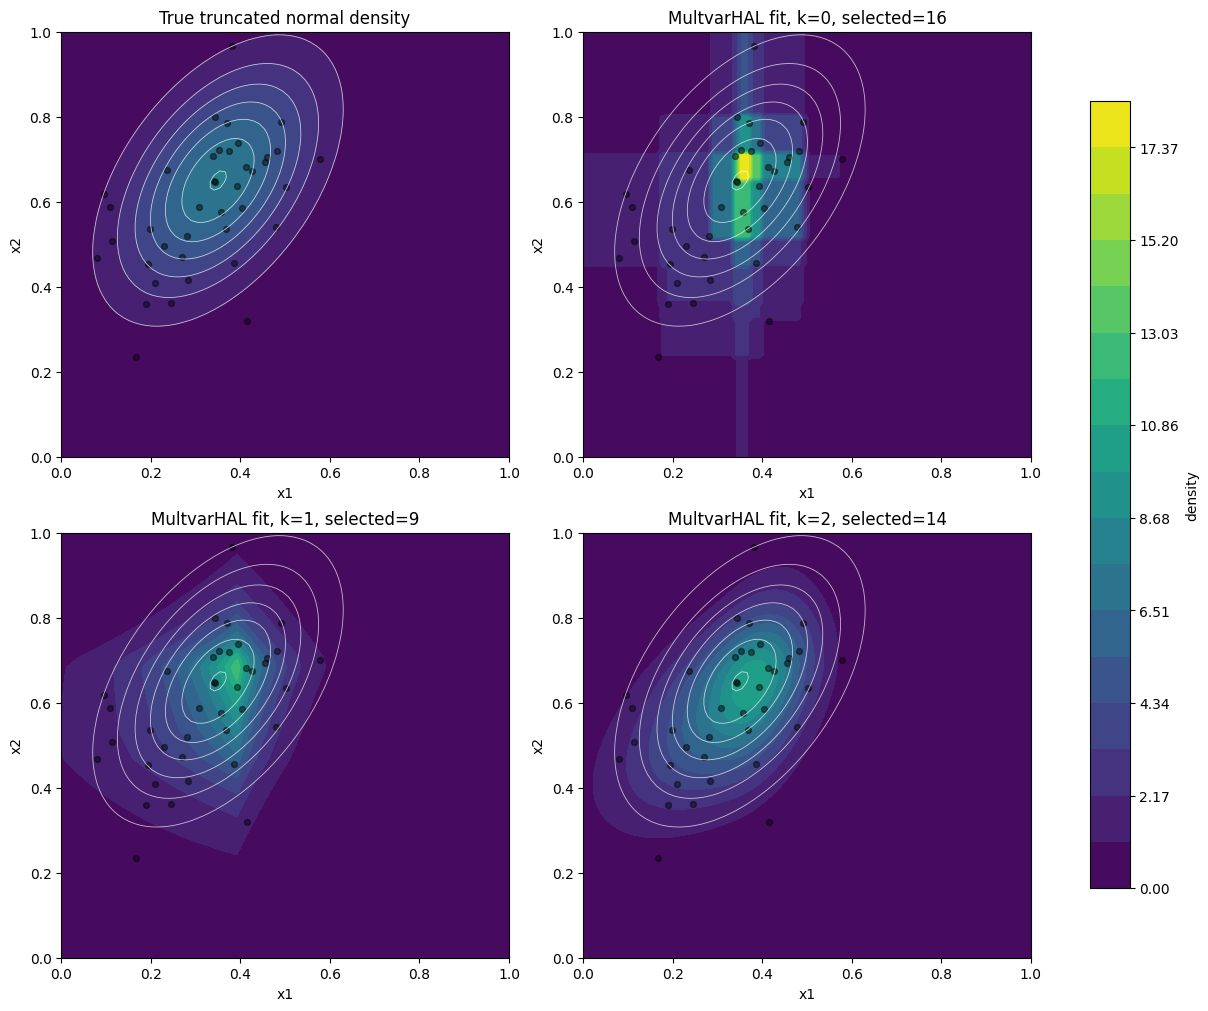

In [17]:
surface_vmax = max(
    float(np.max(true_density_grid)),
    *(float(np.max(grid)) for grid in fit_density_grids.values()),
)
levels = np.linspace(0.0, surface_vmax, 18)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
plot_panels = [("truth", true_density_grid)] + [
    (f"k={order}", fit_density_grids[order])
    for order in ESTIMATOR_CONFIG["orders"]
]

for ax, (label, density_grid) in zip(axes.flat, plot_panels):
    contour = ax.contourf(
        plot_mesh_x1,
        plot_mesh_x2,
        density_grid,
        levels=levels,
        cmap="viridis",
    )
    ax.contour(
        plot_mesh_x1,
        plot_mesh_x2,
        true_density_grid,
        levels=levels[1:],
        colors="white",
        linewidths=0.6,
        alpha=0.7,
    )
    ax.scatter(train_bivariate["x1"], train_bivariate["x2"], s=18, c="black", alpha=0.45)
    ax.set_xlim(*truth_sampler.bounds[0])
    ax.set_ylim(*truth_sampler.bounds[1])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if label == "truth":
        ax.set_title("True truncated normal density")
    else:
        order = int(label.split("=")[1])
        selected_count = int(selected_basis_tables[order].shape[0])
        ax.set_title(f"MultvarHAL fit, {label}, selected={selected_count}")

fig.colorbar(contour, ax=axes, shrink=0.85, label="density")
plt.show()

## 3D Surface View

This repeats the truth and fitted densities as 3D surfaces so the peak shape and local roughness are easier to see. The training sample points are overlaid at their corresponding density heights.

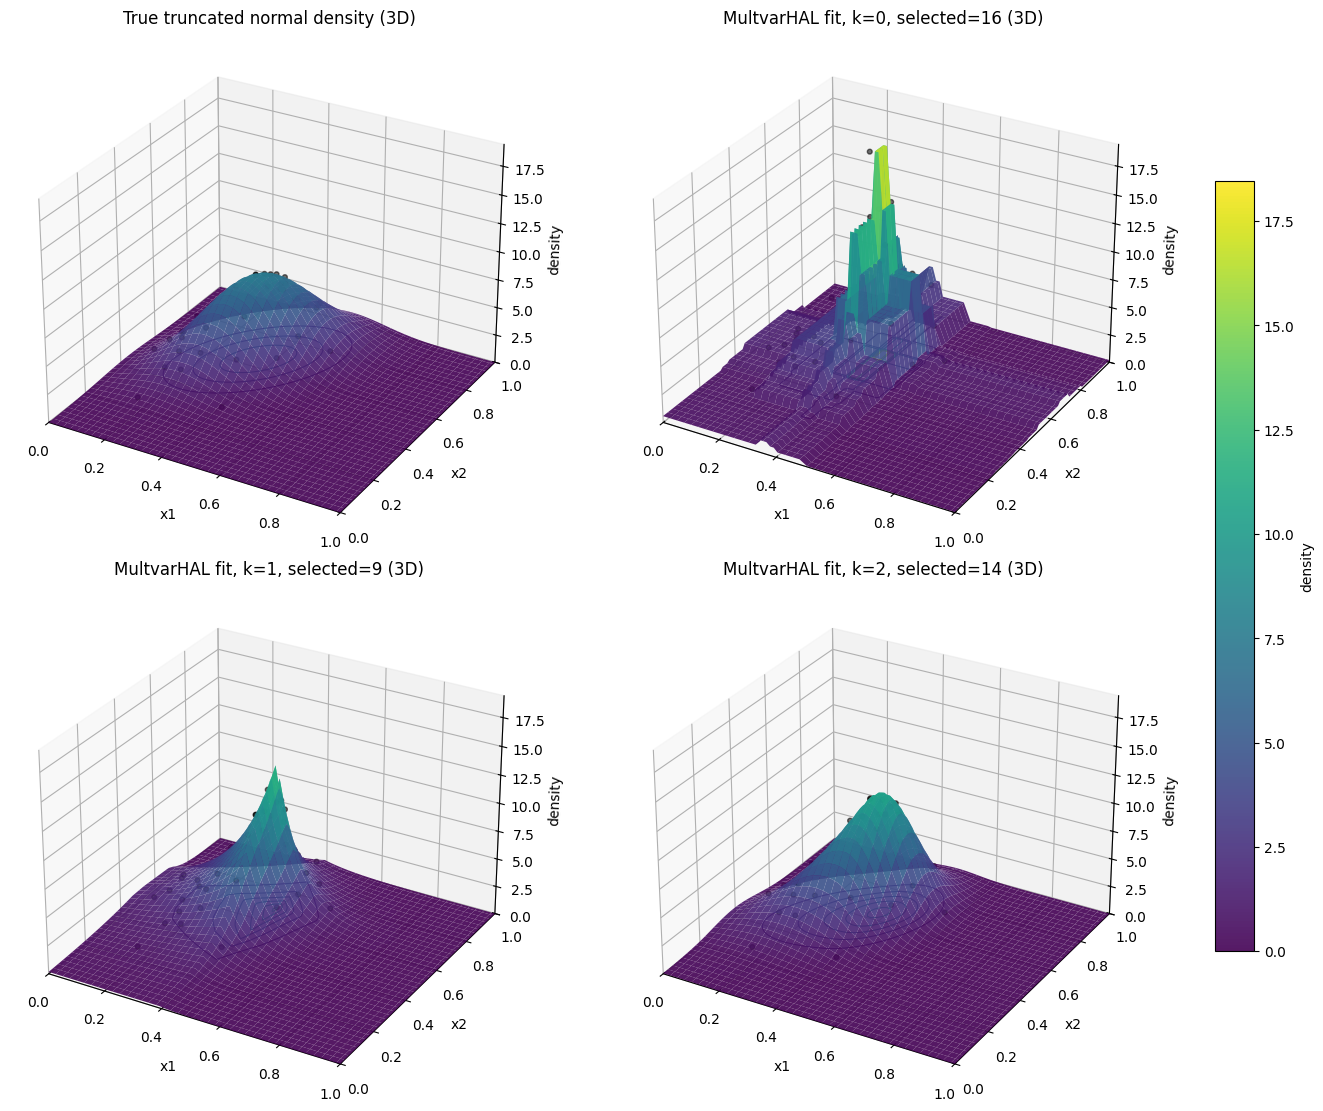

In [18]:
surface_vmax_3d = max(
    float(np.max(true_density_grid)),
    *(float(np.max(grid)) for grid in fit_density_grids.values()),
)
levels_3d = np.linspace(0.0, surface_vmax_3d, 10)
plot_panels_3d = [("truth", true_density_grid)] + [
    (f"k={order}", fit_density_grids[order])
    for order in ESTIMATOR_CONFIG["orders"]
]

fig = plt.figure(figsize=(14, 11), constrained_layout=True)
axes_3d = []

for panel_idx, (label, density_grid) in enumerate(plot_panels_3d, start=1):
    ax = fig.add_subplot(2, 2, panel_idx, projection="3d")
    axes_3d.append(ax)
    surface = ax.plot_surface(
        plot_mesh_x1,
        plot_mesh_x2,
        density_grid,
        cmap="viridis",
        vmin=0.0,
        vmax=surface_vmax_3d,
        linewidth=0,
        antialiased=True,
        alpha=0.9,
    )
    ax.contour(
        plot_mesh_x1,
        plot_mesh_x2,
        density_grid,
        zdir="z",
        offset=0.0,
        levels=levels_3d,
        cmap="viridis",
        linewidths=0.8,
    )

    if label == "truth":
        sample_density = truth_sampler.compute_density(train_bivariate)
        ax.set_title("True truncated normal density (3D)")
    else:
        order = int(label.split("=")[1])
        sample_density = models[order].get_density_at_points(train_bivariate)
        selected_count = int(selected_basis_tables[order].shape[0])
        ax.set_title(f"MultvarHAL fit, {label}, selected={selected_count} (3D)")

    ax.scatter(
        train_bivariate["x1"],
        train_bivariate["x2"],
        sample_density,
        c="black",
        s=12,
        alpha=0.55,
    )
    ax.set_xlim(*truth_sampler.bounds[0])
    ax.set_ylim(*truth_sampler.bounds[1])
    ax.set_zlim(0.0, surface_vmax_3d * 1.05)
    ax.view_init(elev=28, azim=-60)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("density")

fig.colorbar(surface, ax=axes_3d, shrink=0.72, pad=0.06, label="density")
plt.show()

In [19]:
for order in ESTIMATOR_CONFIG["orders"]:
    print(
        f"k={order}, M={ESTIMATOR_CONFIG['norm_constraints_M'][order]}: "
        f"selected {selected_basis_tables[order].shape[0]} basis terms "
        f"with |coefficient| > {ESTIMATOR_CONFIG['selection_tol']}"
    )
    print(f"Normalization checks: {fit_normalization_checks[order]}")
    display(selected_basis_summaries[order])
    display(selected_basis_tables[order])

k=0, M=8.0: selected 16 basis terms with |coefficient| > 0.0001
Normalization checks: {'train_midpoint_integral': 0.9999999999999999, 'fine_midpoint_integral': 1.1591393991614063, 'integral_gap': 0.1591393991614064}


,term_type,section_size,count,abs_coefficient_sum
0,poly,0,1,0.280698
1,section-1,1,11,6.040304
2,full,2,4,1.959695


,basis_index,coefficient,abs_coefficient,family,term_type,section,section_size,complement,knot_row,exponents,name
0,15,-1.386294,1.386294,sectional,section-1,"(x1,)",1,"(x2,)",14.0,"(0,)",I(x1 >= 0.501)
1,80,-0.780158,0.780158,sectional,section-1,"(x2,)",1,"(x1,)",39.0,"(0,)",I(x2 >= 0.800)
2,92,0.756434,0.756434,sectional,full,"(x1, x2)",2,(),11.0,(),I(x1 >= 0.282) * I(x2 >= 0.519)
3,104,0.741120,0.741120,sectional,full,"(x1, x2)",2,(),23.0,(),I(x1 >= 0.168) * I(x2 >= 0.235)
4,50,-0.659014,0.659014,sectional,section-1,"(x2,)",1,"(x1,)",9.0,"(0,)",I(x2 >= 0.721)
5,35,0.649516,0.649516,sectional,section-1,"(x1,)",1,"(x2,)",34.0,"(0,)",I(x1 >= 0.340)
6,22,-0.559615,0.559615,sectional,section-1,"(x1,)",1,"(x2,)",21.0,"(0,)",I(x1 >= 0.481)
7,39,-0.538996,0.538996,sectional,section-1,"(x1,)",1,"(x2,)",38.0,"(0,)",I(x1 >= 0.403)
8,106,0.364737,0.364737,sectional,full,"(x1, x2)",2,(),25.0,(),I(x1 >= 0.342) * I(x2 >= 0.649)
9,42,0.362269,0.362269,sectional,section-1,"(x2,)",1,"(x1,)",1.0,"(0,)",I(x2 >= 0.453)


k=1, M=50.0: selected 9 basis terms with |coefficient| > 0.0001
Normalization checks: {'train_midpoint_integral': 0.9999999999999993, 'fine_midpoint_integral': 1.0053915874485115, 'integral_gap': 0.005391587448512203}


,term_type,section_size,count,abs_coefficient_sum
0,poly,0,3,14.313545
1,section-1,1,6,36.567737


,basis_index,coefficient,abs_coefficient,family,term_type,section,section_size,complement,knot_row,exponents,name
0,48,-19.075624,19.075624,sectional,section-1,"(x1,)",1,"(x2,)",22.0,"(0,)",(x1 - 0.392)_+
1,3,9.535452,9.535452,parametric,poly,(),0,"(x1, x2)",NaN,"(1, 1)",x1 * x2
2,92,-7.174954,7.174954,sectional,section-1,"(x2,)",1,"(x1,)",4.0,"(0,)",(x2 - 0.682)_+
3,152,-5.729050,5.729050,sectional,section-1,"(x2,)",1,"(x1,)",34.0,"(0,)",(x2 - 0.706)_+
4,1,3.896653,3.896653,parametric,poly,(),0,"(x1, x2)",NaN,"(0, 1)",x2
5,104,-3.042736,3.042736,sectional,section-1,"(x2,)",1,"(x1,)",10.0,"(0,)",(x2 - 0.468)_+
6,148,-1.545197,1.545197,sectional,section-1,"(x2,)",1,"(x1,)",32.0,"(0,)",(x2 - 0.536)_+
7,0,-0.881440,0.881440,parametric,poly,(),0,"(x1, x2)",NaN,"(0, 0)",Intercept
8,88,-0.000176,0.000176,sectional,section-1,"(x2,)",1,"(x1,)",2.0,"(0,)",(x2 - 0.536)_+


k=2, M=200.0: selected 14 basis terms with |coefficient| > 0.0001
Normalization checks: {'train_midpoint_integral': 0.9999999999999998, 'fine_midpoint_integral': 0.9999108371262477, 'integral_gap': 8.916287375204668e-05}


,term_type,section_size,count,abs_coefficient_sum
0,poly,0,5,68.028443
1,section-1,1,9,133.485492


,basis_index,coefficient,abs_coefficient,family,term_type,section,section_size,complement,knot_row,exponents,name
0,84,-32.911490,32.911490,sectional,section-1,"(x1,)",1,"(x2,)",25.0,"(0,)",(x1 - 0.342)_+^2
1,198,-28.525495,28.525495,sectional,section-1,"(x2,)",1,"(x1,)",23.0,"(0,)",(x2 - 0.235)_+^2
2,50,-28.193139,28.193139,sectional,section-1,"(x1,)",1,"(x2,)",13.0,"(2,)",x2^2 * (x1 - 0.307)_+^2
3,246,25.892223,25.892223,sectional,section-1,"(x2,)",1,"(x1,)",39.0,"(0,)",(x2 - 0.800)_+^2
4,6,-21.472556,21.472556,parametric,poly,(),0,"(x1, x2)",NaN,"(2, 0)",x1^2
5,4,21.184895,21.184895,parametric,poly,(),0,"(x1, x2)",NaN,"(1, 1)",x1 * x2
6,171,-17.959129,17.959129,sectional,section-1,"(x2,)",1,"(x1,)",14.0,"(0,)",(x2 - 0.634)_+^2
7,5,14.708690,14.708690,parametric,poly,(),0,"(x1, x2)",NaN,"(1, 2)",x1 * x2^2
8,1,9.147235,9.147235,parametric,poly,(),0,"(x1, x2)",NaN,"(0, 1)",x2
9,0,-1.515067,1.515067,parametric,poly,(),0,"(x1, x2)",NaN,"(0, 0)",Intercept


## Recovery Experiment: Known Sparse Structure

A good estimation check is to fit a truth with known sparse structure and see whether the selected basis reflects it. This first recovery experiment uses a polynomial log-density on `[0, 1]^2` with no interaction terms, so the true active structure is entirely `poly`.

In [20]:
class PolynomialLogDensityTruth:
    def __init__(
        self,
        coefficients: dict[tuple[int, ...], float],
        support: tuple[tuple[float, float], tuple[float, float]] = ((0.0, 1.0), (0.0, 1.0)),
        normalization_points_per_dim: int = 160,
    ) -> None:
        self.coefficients = {tuple(map(int, exponents)): float(value) for exponents, value in coefficients.items()}
        self.support = support
        self.lower = np.array([bound[0] for bound in support], dtype=float)
        self.upper = np.array([bound[1] for bound in support], dtype=float)
        self.proposal_density_ = 1.0 / np.prod(self.upper - self.lower)
        self._normalization_points_, self._normalization_weights_, _ = build_midpoint_quadrature(
            self.support,
            normalization_points_per_dim,
        )
        log_unnormalized = self.log_unnormalized(self._normalization_points_)
        self.log_normalizer_ = float(logsumexp(log_unnormalized + np.log(self._normalization_weights_)))
        self.max_density_upper_ = float(np.max(np.exp(log_unnormalized - self.log_normalizer_))) * 1.05

    def _inside_support(self, points: np.ndarray) -> np.ndarray:
        return np.all((points >= self.lower) & (points <= self.upper), axis=1)

    def log_unnormalized(self, points: pd.DataFrame | np.ndarray) -> np.ndarray:
        arr = _coerce_multivariate_data(points).to_numpy(dtype=float)
        log_density = np.zeros(arr.shape[0], dtype=float)
        for exponents, coefficient in self.coefficients.items():
            log_density += coefficient * np.prod(arr ** np.asarray(exponents, dtype=float), axis=1)
        return log_density

    def compute_density(self, points: pd.DataFrame | np.ndarray) -> np.ndarray:
        arr = _coerce_multivariate_data(points).to_numpy(dtype=float)
        density = np.zeros(arr.shape[0], dtype=float)
        inside = self._inside_support(arr)
        if np.any(inside):
            density[inside] = np.exp(self.log_unnormalized(arr[inside]) - self.log_normalizer_)
        return density

    def density_on_mesh(self, mesh_x1: np.ndarray, mesh_x2: np.ndarray) -> np.ndarray:
        grid_points = np.column_stack([mesh_x1.ravel(), mesh_x2.ravel()])
        density = self.compute_density(grid_points)
        return density.reshape(mesh_x1.shape)

    def generate_samples(self, n_samples: int, seed: int = 0) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        accepted_batches: list[np.ndarray] = []
        accepted_total = 0
        rejection_bound = self.max_density_upper_ / self.proposal_density_ * 1.05

        while accepted_total < n_samples:
            batch_size = max(1000, 6 * (n_samples - accepted_total))
            proposals = rng.uniform(self.lower, self.upper, size=(batch_size, self.lower.size))
            density = self.compute_density(proposals)
            accept_prob = density / (rejection_bound * self.proposal_density_)
            accepted = proposals[rng.uniform(size=batch_size) < accept_prob]
            if accepted.size == 0:
                continue
            accepted_batches.append(accepted)
            accepted_total += accepted.shape[0]

        sample = np.vstack(accepted_batches)[:n_samples]
        return pd.DataFrame(sample, columns=[f"x{i + 1}" for i in range(sample.shape[1])])

    def active_terms_table(self) -> pd.DataFrame:
        rows = []
        variable_names = ["x1", "x2"]
        for exponents, coefficient in sorted(self.coefficients.items()):
            rows.append(
                {
                    "term_type": "poly",
                    "section_size": 0,
                    "exponents": exponents,
                    "coefficient": coefficient,
                    "name": _format_polynomial_name(exponents, variable_names),
                }
            )
        return pd.DataFrame(rows)


RECOVERY_CONFIG = {
    "coefficients": {
        (1, 0): 1.4,
        (2, 0): -2.0,
        (0, 1): 1.0,
        (0, 2): -1.6,
    },
    "n_train": 80,
    "seed": 2026,
    "fit_k": 2,
    "solver": "ECOS",
    "norm_constraint_M": 8.0,
    "quadrature_points_per_dim": 28,
    "normalization_check_points_per_dim": 140,
    "plot_points_per_dim": 80,
}

recovery_truth = PolynomialLogDensityTruth(
    coefficients=RECOVERY_CONFIG["coefficients"],
    support=((0.0, 1.0), (0.0, 1.0)),
    normalization_points_per_dim=160,
)
recovery_data = recovery_truth.generate_samples(
    RECOVERY_CONFIG["n_train"],
    seed=RECOVERY_CONFIG["seed"],
)
recovery_model = MultvarHAL(
    k=RECOVERY_CONFIG["fit_k"],
    norm_constraint=RECOVERY_CONFIG["norm_constraint_M"],
    support=recovery_truth.support,
    quadrature_points_per_dim=RECOVERY_CONFIG["quadrature_points_per_dim"],
    solver=RECOVERY_CONFIG["solver"],
    selection_tol=1e-4,
)
recovery_model.fit(recovery_data)

recovery_axis = np.linspace(0.0, 1.0, RECOVERY_CONFIG["plot_points_per_dim"])
recovery_mesh_x1, recovery_mesh_x2 = np.meshgrid(recovery_axis, recovery_axis, indexing="xy")
recovery_true_grid = recovery_truth.density_on_mesh(recovery_mesh_x1, recovery_mesh_x2)
recovery_fit_grid = recovery_model.density_on_mesh(recovery_mesh_x1, recovery_mesh_x2)
recovery_cell_area = (1.0 / (RECOVERY_CONFIG["plot_points_per_dim"] - 1)) ** 2
recovery_approx_l1_error = float(np.sum(np.abs(recovery_fit_grid - recovery_true_grid)) * recovery_cell_area)

recovery_truth_summary = summarize_basis_catalog(
    recovery_truth.active_terms_table(),
    coefficient_col="coefficient",
)
recovery_selected_summary = recovery_model.selected_basis_summary()

recovery_summary = pd.DataFrame(
    [
        {
            **recovery_model.summary(),
            "approx_l1_error": recovery_approx_l1_error,
            "train_midpoint_integral": recovery_model.normalization_integral(),
            "fine_midpoint_integral": recovery_model.normalization_integral(
                points_per_dim=RECOVERY_CONFIG["normalization_check_points_per_dim"]
            ),
            **extract_term_type_metrics(recovery_selected_summary, prefix="selected"),
        }
    ]
)
recovery_summary["integral_gap"] = np.abs(
    recovery_summary["train_midpoint_integral"] - recovery_summary["fine_midpoint_integral"]
)

recovery_structure_comparison_df = pd.DataFrame(
    [
        {"source": "true", **extract_term_type_metrics(recovery_truth_summary)},
        {"source": "selected", **extract_term_type_metrics(recovery_selected_summary)},
    ]
)

print(
    {
        "truth_coefficients": RECOVERY_CONFIG["coefficients"],
        "n_train": RECOVERY_CONFIG["n_train"],
        "fit_k": RECOVERY_CONFIG["fit_k"],
        "solver": RECOVERY_CONFIG["solver"],
        "norm_constraint_M": RECOVERY_CONFIG["norm_constraint_M"],
    }
)

display(recovery_truth.active_terms_table())
display(recovery_summary)
display(recovery_structure_comparison_df)
display(recovery_selected_summary)

{'truth_coefficients': {(1, 0): 1.4, (2, 0): -2.0, (0, 1): 1.0, (0, 2): -1.6}, 'n_train': 80, 'fit_k': 2, 'solver': 'ECOS', 'norm_constraint_M': 8.0}


,term_type,section_size,exponents,coefficient,name
0,poly,0,"(0, 1)",1.0,x2
1,poly,0,"(0, 2)",-1.6,x2^2
2,poly,0,"(1, 0)",1.4,x1
3,poly,0,"(2, 0)",-2.0,x1^2


,k,solver_status,basis_width,quadrature_grid_size,fit_time_seconds,selected_basis_count,selected_nonintercept,norm_constraint_M,norm_used,objective_value,train_loglik,near_zero_variance_fraction,max_abs_correlation_subset,approx_l1_error,train_midpoint_integral,fine_midpoint_integral,selected_poly_count,selected_poly_abs_mass,selected_section_1_count,selected_section_1_abs_mass,selected_full_count,selected_full_abs_mass,integral_gap
0,2,optimal,569,784,1.55432,9,8,8.0,7.999452,-7.541905,7.541756,0.035149,1.0,0.097292,1.0,0.999758,3,1.937259,6,6.153314,0,0.0,0.000242


,source,poly_count,poly_abs_mass,section_1_count,section_1_abs_mass,full_count,full_abs_mass
0,true,4,6.000000,0,0.000000,0,0.0
1,selected,3,1.937259,6,6.153314,0,0.0


,term_type,section_size,count,abs_coefficient_sum
0,poly,0,3,1.937259
1,section-1,1,6,6.153314


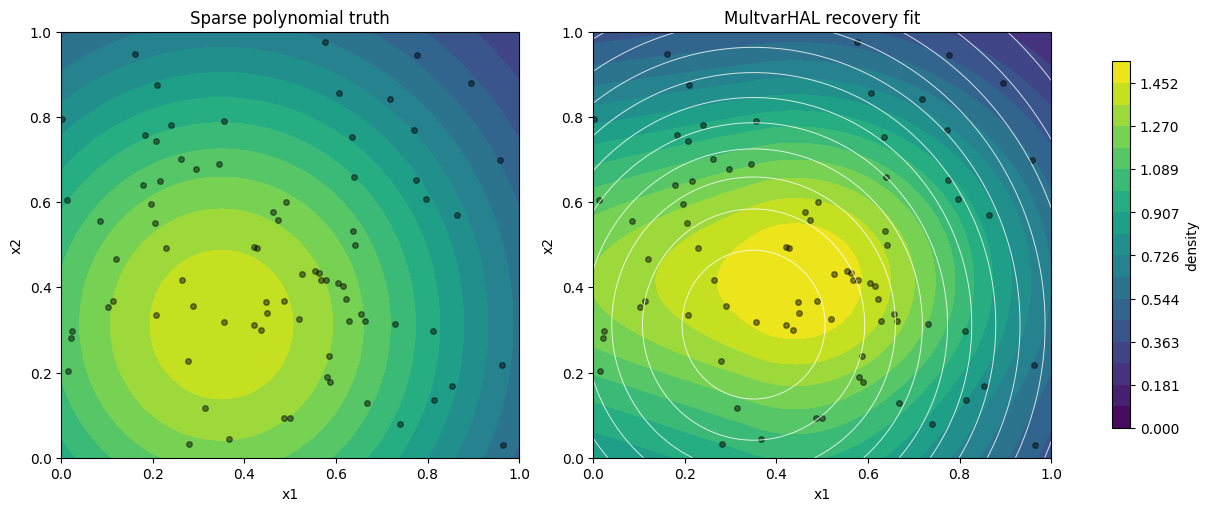

,basis_index,coefficient,abs_coefficient,family,term_type,section,section_size,complement,knot_row,exponents,name
0,12,-2.586489,2.586489,sectional,section-1,"(x1,)",1,"(x2,)",1.0,"(0,)",(x1 - 0.355)_+^2
1,474,-2.056091,2.056091,sectional,section-1,"(x2,)",1,"(x1,)",75.0,"(0,)",(x2 - 0.203)_+^2
2,1,1.365979,1.365979,parametric,poly,(),0,"(x1, x2)",NaN,"(0, 1)",x2
3,384,-1.260708,1.260708,sectional,section-1,"(x2,)",1,"(x1,)",45.0,"(0,)",(x2 - 0.217)_+^2
4,3,0.480159,0.480159,parametric,poly,(),0,"(x1, x2)",NaN,"(1, 0)",x1
5,117,-0.249390,0.249390,sectional,section-1,"(x1,)",1,"(x2,)",36.0,"(0,)",(x1 - 0.355)_+^2
6,0,-0.091121,0.091121,parametric,poly,(),0,"(x1, x2)",NaN,"(0, 0)",Intercept
7,165,-0.000435,0.000435,sectional,section-1,"(x1,)",1,"(x2,)",52.0,"(0,)",(x1 - 0.365)_+^2
8,135,-0.000200,0.000200,sectional,section-1,"(x1,)",1,"(x2,)",42.0,"(0,)",(x1 - 0.344)_+^2


In [21]:
recovery_vmax = max(float(np.max(recovery_true_grid)), float(np.max(recovery_fit_grid)))
recovery_levels = np.linspace(0.0, recovery_vmax, 18)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
recovery_panels = [
    ("Sparse polynomial truth", recovery_true_grid),
    ("MultvarHAL recovery fit", recovery_fit_grid),
]

for ax, (label, density_grid) in zip(axes, recovery_panels):
    contour = ax.contourf(
        recovery_mesh_x1,
        recovery_mesh_x2,
        density_grid,
        levels=recovery_levels,
        cmap="viridis",
    )
    ax.scatter(recovery_data["x1"], recovery_data["x2"], s=16, c="black", alpha=0.45)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_title(label)

axes[1].contour(
    recovery_mesh_x1,
    recovery_mesh_x2,
    recovery_true_grid,
    levels=recovery_levels[1:],
    colors="white",
    linewidths=0.7,
    alpha=0.8,
)
fig.colorbar(contour, ax=axes, shrink=0.86, label="density")
plt.show()

display(recovery_model.selected_basis_.head(15))

## Recovery Experiment: Known Full Interaction Signal

This second recovery experiment adds a genuine full-section term to the true log-density. The goal is to check whether the fitted model uses noticeably more `full` structure when the truth really contains it.

In [22]:
class InteractionLogDensityTruth:
    def __init__(
        self,
        poly_coefficients: dict[tuple[int, ...], float],
        interaction_weight: float,
        interaction_knot: tuple[float, float],
        support: tuple[tuple[float, float], tuple[float, float]] = ((0.0, 1.0), (0.0, 1.0)),
        normalization_points_per_dim: int = 160,
    ) -> None:
        self.poly_coefficients = {
            tuple(map(int, exponents)): float(value)
            for exponents, value in poly_coefficients.items()
        }
        self.interaction_weight = float(interaction_weight)
        self.interaction_knot = tuple(float(value) for value in interaction_knot)
        self.support = support
        self.lower = np.array([bound[0] for bound in support], dtype=float)
        self.upper = np.array([bound[1] for bound in support], dtype=float)
        self.proposal_density_ = 1.0 / np.prod(self.upper - self.lower)
        self._normalization_points_, self._normalization_weights_, _ = build_midpoint_quadrature(
            self.support,
            normalization_points_per_dim,
        )
        log_unnormalized = self.log_unnormalized(self._normalization_points_)
        self.log_normalizer_ = float(logsumexp(log_unnormalized + np.log(self._normalization_weights_)))
        self.max_density_upper_ = float(np.max(np.exp(log_unnormalized - self.log_normalizer_))) * 1.05

    def _inside_support(self, points: np.ndarray) -> np.ndarray:
        return np.all((points >= self.lower) & (points <= self.upper), axis=1)

    def log_unnormalized(self, points: pd.DataFrame | np.ndarray) -> np.ndarray:
        arr = _coerce_multivariate_data(points).to_numpy(dtype=float)
        x1 = arr[:, 0]
        x2 = arr[:, 1]
        log_density = np.zeros(arr.shape[0], dtype=float)
        for exponents, coefficient in self.poly_coefficients.items():
            log_density += coefficient * np.prod(arr ** np.asarray(exponents, dtype=float), axis=1)
        log_density += self.interaction_weight * np.maximum(x1 - self.interaction_knot[0], 0.0) * np.maximum(x2 - self.interaction_knot[1], 0.0)
        return log_density

    def compute_density(self, points: pd.DataFrame | np.ndarray) -> np.ndarray:
        arr = _coerce_multivariate_data(points).to_numpy(dtype=float)
        density = np.zeros(arr.shape[0], dtype=float)
        inside = self._inside_support(arr)
        if np.any(inside):
            density[inside] = np.exp(self.log_unnormalized(arr[inside]) - self.log_normalizer_)
        return density

    def density_on_mesh(self, mesh_x1: np.ndarray, mesh_x2: np.ndarray) -> np.ndarray:
        grid_points = np.column_stack([mesh_x1.ravel(), mesh_x2.ravel()])
        density = self.compute_density(grid_points)
        return density.reshape(mesh_x1.shape)

    def generate_samples(self, n_samples: int, seed: int = 0) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        accepted_batches: list[np.ndarray] = []
        accepted_total = 0
        rejection_bound = self.max_density_upper_ / self.proposal_density_ * 1.05

        while accepted_total < n_samples:
            batch_size = max(1000, 6 * (n_samples - accepted_total))
            proposals = rng.uniform(self.lower, self.upper, size=(batch_size, self.lower.size))
            density = self.compute_density(proposals)
            accept_prob = density / (rejection_bound * self.proposal_density_)
            accepted = proposals[rng.uniform(size=batch_size) < accept_prob]
            if accepted.size == 0:
                continue
            accepted_batches.append(accepted)
            accepted_total += accepted.shape[0]

        sample = np.vstack(accepted_batches)[:n_samples]
        return pd.DataFrame(sample, columns=[f"x{i + 1}" for i in range(sample.shape[1])])

    def active_terms_table(self) -> pd.DataFrame:
        rows = []
        variable_names = ["x1", "x2"]
        for exponents, coefficient in sorted(self.poly_coefficients.items()):
            rows.append(
                {
                    "term_type": "poly",
                    "section_size": 0,
                    "exponents": exponents,
                    "coefficient": coefficient,
                    "name": _format_polynomial_name(exponents, variable_names),
                }
            )
        rows.append(
            {
                "term_type": "full",
                "section_size": 2,
                "exponents": (),
                "coefficient": self.interaction_weight,
                "name": f"(x1 - {self.interaction_knot[0]:.3f})_+ * (x2 - {self.interaction_knot[1]:.3f})_+",
            }
        )
        return pd.DataFrame(rows)


INTERACTION_RECOVERY_CONFIG = {
    "poly_coefficients": {
        (1, 0): 0.6,
        (2, 0): -0.8,
        (0, 1): 0.8,
        (0, 2): -1.0,
    },
    "interaction_weight": 10.0,
    "interaction_knot": (0.4, 0.6),
    "n_train": 100,
    "seed": 2027,
    "fit_k": 1,
    "solver": "ECOS",
    "norm_constraint_M": 20.0,
    "quadrature_points_per_dim": 28,
    "normalization_check_points_per_dim": 140,
    "plot_points_per_dim": 80,
}

interaction_truth = InteractionLogDensityTruth(
    poly_coefficients=INTERACTION_RECOVERY_CONFIG["poly_coefficients"],
    interaction_weight=INTERACTION_RECOVERY_CONFIG["interaction_weight"],
    interaction_knot=INTERACTION_RECOVERY_CONFIG["interaction_knot"],
    support=((0.0, 1.0), (0.0, 1.0)),
    normalization_points_per_dim=160,
)
interaction_data = interaction_truth.generate_samples(
    INTERACTION_RECOVERY_CONFIG["n_train"],
    seed=INTERACTION_RECOVERY_CONFIG["seed"],
)
interaction_model = MultvarHAL(
    k=INTERACTION_RECOVERY_CONFIG["fit_k"],
    norm_constraint=INTERACTION_RECOVERY_CONFIG["norm_constraint_M"],
    support=interaction_truth.support,
    quadrature_points_per_dim=INTERACTION_RECOVERY_CONFIG["quadrature_points_per_dim"],
    solver=INTERACTION_RECOVERY_CONFIG["solver"],
    selection_tol=1e-4,
)
interaction_model.fit(interaction_data)

interaction_axis = np.linspace(0.0, 1.0, INTERACTION_RECOVERY_CONFIG["plot_points_per_dim"])
interaction_mesh_x1, interaction_mesh_x2 = np.meshgrid(interaction_axis, interaction_axis, indexing="xy")
interaction_true_grid = interaction_truth.density_on_mesh(interaction_mesh_x1, interaction_mesh_x2)
interaction_fit_grid = interaction_model.density_on_mesh(interaction_mesh_x1, interaction_mesh_x2)
interaction_cell_area = (1.0 / (INTERACTION_RECOVERY_CONFIG["plot_points_per_dim"] - 1)) ** 2
interaction_approx_l1_error = float(np.sum(np.abs(interaction_fit_grid - interaction_true_grid)) * interaction_cell_area)

interaction_truth_summary = summarize_basis_catalog(
    interaction_truth.active_terms_table(),
    coefficient_col="coefficient",
)
interaction_selected_summary = interaction_model.selected_basis_summary()
interaction_summary = pd.DataFrame(
    [
        {
            **interaction_model.summary(),
            "approx_l1_error": interaction_approx_l1_error,
            "train_midpoint_integral": interaction_model.normalization_integral(),
            "fine_midpoint_integral": interaction_model.normalization_integral(
                points_per_dim=INTERACTION_RECOVERY_CONFIG["normalization_check_points_per_dim"]
            ),
            **extract_term_type_metrics(interaction_selected_summary, prefix="selected"),
        }
    ]
)
interaction_summary["integral_gap"] = np.abs(
    interaction_summary["train_midpoint_integral"] - interaction_summary["fine_midpoint_integral"]
)
interaction_structure_comparison_df = pd.DataFrame(
    [
        {"source": "true", **extract_term_type_metrics(interaction_truth_summary)},
        {"source": "selected", **extract_term_type_metrics(interaction_selected_summary)},
    ]
)

print(
    {
        "interaction_knot": INTERACTION_RECOVERY_CONFIG["interaction_knot"],
        "interaction_weight": INTERACTION_RECOVERY_CONFIG["interaction_weight"],
        "n_train": INTERACTION_RECOVERY_CONFIG["n_train"],
        "fit_k": INTERACTION_RECOVERY_CONFIG["fit_k"],
        "solver": INTERACTION_RECOVERY_CONFIG["solver"],
        "norm_constraint_M": INTERACTION_RECOVERY_CONFIG["norm_constraint_M"],
    }
)

display(interaction_truth.active_terms_table())
display(interaction_summary)
display(interaction_structure_comparison_df)
display(interaction_selected_summary)

{'interaction_knot': (0.4, 0.6), 'interaction_weight': 10.0, 'n_train': 100, 'fit_k': 1, 'solver': 'ECOS', 'norm_constraint_M': 20.0}


,term_type,section_size,exponents,coefficient,name
0,poly,0,"(0, 1)",0.8,x2
1,poly,0,"(0, 2)",-1.0,x2^2
2,poly,0,"(1, 0)",0.6,x1
3,poly,0,"(2, 0)",-0.8,x1^2
4,full,2,(),10.0,(x1 - 0.400)_+ * (x2 - 0.600)_+


,k,solver_status,basis_width,quadrature_grid_size,fit_time_seconds,selected_basis_count,selected_nonintercept,norm_constraint_M,norm_used,objective_value,train_loglik,near_zero_variance_fraction,max_abs_correlation_subset,approx_l1_error,train_midpoint_integral,fine_midpoint_integral,selected_poly_count,selected_poly_abs_mass,selected_section_1_count,selected_section_1_abs_mass,selected_full_count,selected_full_abs_mass,integral_gap
0,1,optimal,504,784,0.880527,24,23,20.0,19.998024,-16.295457,16.295257,0.019841,0.999744,0.22087,1.0,1.000378,3,0.624355,20,15.784135,1,3.605632,0.000378


,source,poly_count,poly_abs_mass,section_1_count,section_1_abs_mass,full_count,full_abs_mass
0,true,4,3.200000,0,0.000000,1,10.000000
1,selected,3,0.624355,20,15.784135,1,3.605632


,term_type,section_size,count,abs_coefficient_sum
0,poly,0,3,0.624355
1,section-1,1,20,15.784135
2,full,2,1,3.605632


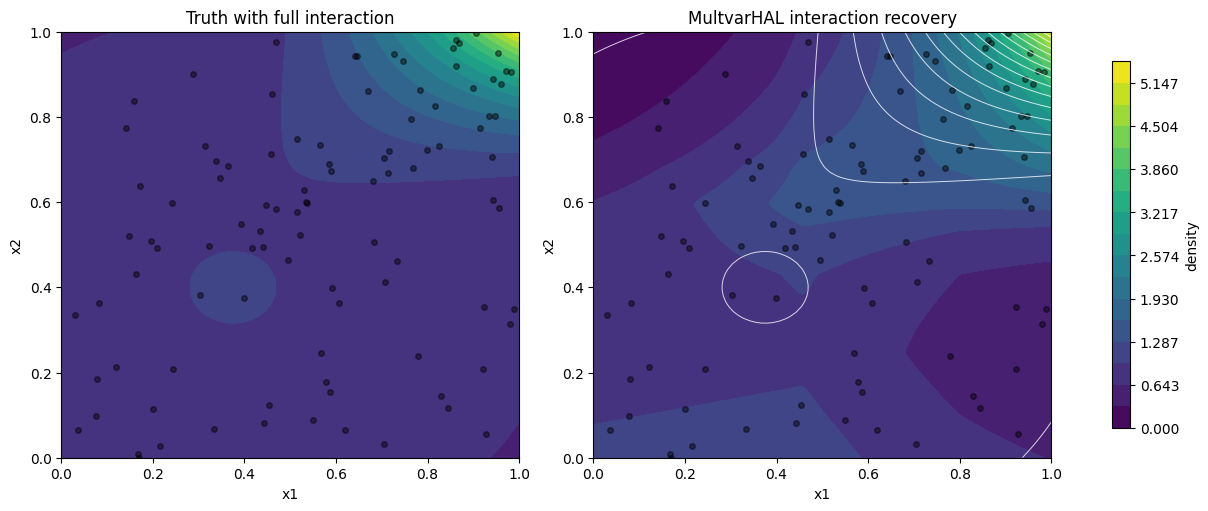

,basis_index,coefficient,abs_coefficient,family,term_type,section,section_size,complement,knot_row,exponents,name
0,248,-3.848639,3.848639,sectional,section-1,"(x2,)",1,"(x1,)",22.0,"(0,)",(x2 - 0.599)_+
1,481,3.605632,3.605632,sectional,full,"(x1, x2)",2,(),77.0,(),(x1 - 0.393)_+ * (x2 - 0.548)_+
2,301,3.571700,3.571700,sectional,section-1,"(x2,)",1,"(x1,)",48.0,"(1,)",x1 * (x2 - 0.431)_+
3,387,2.753125,2.753125,sectional,section-1,"(x2,)",1,"(x1,)",91.0,"(1,)",x1 * (x2 - 0.246)_+
4,115,-1.302924,1.302924,sectional,section-1,"(x1,)",1,"(x2,)",55.0,"(1,)",x2 * (x1 - 0.460)_+
5,114,-1.300147,1.300147,sectional,section-1,"(x1,)",1,"(x2,)",55.0,"(0,)",(x1 - 0.460)_+
6,254,-1.025310,1.025310,sectional,section-1,"(x2,)",1,"(x1,)",25.0,"(0,)",(x2 - 0.679)_+
7,359,0.583824,0.583824,sectional,section-1,"(x2,)",1,"(x1,)",77.0,"(1,)",x1 * (x2 - 0.548)_+
8,112,0.559899,0.559899,sectional,section-1,"(x1,)",1,"(x2,)",54.0,"(0,)",(x1 - 0.799)_+
9,306,-0.439556,0.439556,sectional,section-1,"(x2,)",1,"(x1,)",51.0,"(0,)",(x2 - 0.000)_+


In [23]:
interaction_vmax = max(float(np.max(interaction_true_grid)), float(np.max(interaction_fit_grid)))
interaction_levels = np.linspace(0.0, interaction_vmax, 18)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
interaction_panels = [
    ("Truth with full interaction", interaction_true_grid),
    ("MultvarHAL interaction recovery", interaction_fit_grid),
]

for ax, (label, density_grid) in zip(axes, interaction_panels):
    contour = ax.contourf(
        interaction_mesh_x1,
        interaction_mesh_x2,
        density_grid,
        levels=interaction_levels,
        cmap="viridis",
    )
    ax.scatter(interaction_data["x1"], interaction_data["x2"], s=16, c="black", alpha=0.45)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_title(label)

axes[1].contour(
    interaction_mesh_x1,
    interaction_mesh_x2,
    interaction_true_grid,
    levels=interaction_levels[1:],
    colors="white",
    linewidths=0.7,
    alpha=0.8,
)
fig.colorbar(contour, ax=axes, shrink=0.86, label="density")
plt.show()

display(interaction_model.selected_basis_.head(15))

## Takeaways

This notebook now tests two separate claims.

For basis correctness:
- `create_multivariate_basis(data, k, knot_data=None)` now returns a more theory-facing catalog, including `section_size` and `term_type` (`poly`, `section-1`, `full`, and so on).
- The notebook checks both basis counts and explicit theorem-style formulas for small cases such as `d = 2, k = 1` and `d = 2, k = 2`.
- It also reports simple design-matrix diagnostics to show when the dictionary is becoming highly correlated or poorly scaled.

For estimation correctness:
- `MultvarHAL` follows the repo's univariate HAL pattern: linear log-density, midpoint quadrature for normalization, and an `L1` constraint on non-intercept coefficients.
- Each fit now reports normalization using both the training quadrature and a finer midpoint grid afterward, along with fit time, basis width, and solver status.
- The compact comparison table summarizes selected counts and absolute coefficient mass by term type, so it is easier to compare `k = 0, 1, 2` at similar diagnostic granularity.
- Boundary and near-corner evaluations make edge behavior visible on `[0, 1]^2`.
- The notebook now includes two recovery experiments: one with sparse polynomial truth and one with a genuine full interaction signal.

Natural extensions from here are screening rules for larger dictionaries and eventually moving the basis/estimator code into reusable package modules.